# SMS Spam Classification
Dans ce projet nous allons classifier les SMS en '**spam**' ou '**ham**' :
- **spam** : Des SMS indésirables
- **ham** : Des SMS normales
Et pour l'effectuer , nous allons créer trois modèles . Puis on compare Leurs performances
- - -
## Analyse Exploratoire de Données
### Importation de données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import collections

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,ConfusionMatrixDisplay,classification_report,precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import pickle

In [3]:
df = pd.read_csv("./spam.csv",encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


- - -
## Nettoyage de donnée

In [7]:
# Suppression des colonnes inutiles
df = df[["v1","v2"]]

In [9]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [11]:
df.duplicated().sum()

403

In [13]:
df.drop_duplicates(inplace=True , ignore_index=True)
df.duplicated().sum()

0

In [15]:
df.columns = ["target","messages"]
df.describe().T

,count,unique,top,freq
target,5169,2,ham,4516
messages,5169,5169,"Go until jurong point, crazy.. Available only ...",1


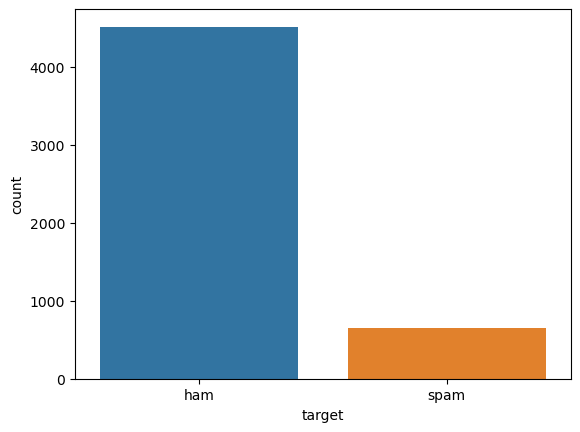

In [23]:
sns.countplot(data=df, x="target",hue="target")
plt.savefig('./compte_target.png')

In [10]:
df["target"].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='word'>

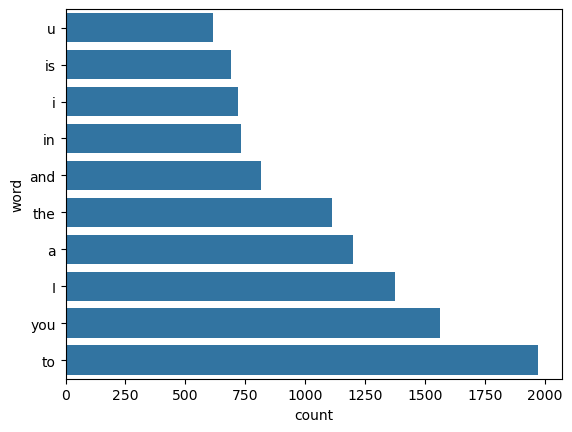

In [11]:
counter = collections.Counter([word for sentence in df["messages"] for word in sentence.split()])

df_counted = pd.DataFrame(counter.most_common(10),columns=["word","count"]).sort_values(by=["count"])
sns.barplot(df_counted,x="count",y="word",orient='horizontal')

On remarque que les mots les plus fréquents sont des mots tels que 'I' , 'a' , 'you' , 'and' ... Or , ces mots n'aide pas dans son sens ou contexte. Cela pourrait endommager le modèle. La prochaine étape est alors de les enlever et soigner le jeu de donnée
- - -
## NORMALIZATION DES TEXTES
Dans les messages, on va généraliser les addresses email , les liens , telephones\
Ensuite, les mots bruyants comme 'I' , 'You' , 'and' , ... seront aussi éliminés car ils ne font qu'endommager notre modèle .\
Enfin , Les textes seront normalisés grace à une technique appelé **lemmatization** qui permet de reduire les mots sous sa forme dans la dictionnaire


In [22]:
lemmatizer = WordNetLemmatizer()
stop_word = set(stopwords.words('english'))
for i in range(df.shape[0]):
    # Substitution des emails , liens , téléphones sous une format uniforme
    mess_1 = re.sub(r'\b[\w\-.]+?@\w+?\.\w{2,4}\b', 'emailaddr', df.iloc[i,1])
    mess_1 = re.sub(r'(http[s]?\S+)|(\w+\.[A-Za-z]{2,4}\S*)', 'httpaddr', mess_1) 
    mess_1 = re.sub(r'£|\$', 'moneysymb', mess_1) 
    mess_1 = re.sub(r'\b(\+\d{1,2}\s)?\d?[\-(.]?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}\b', 'phonenumbr', mess_1) 
    mess_1 = re.sub(r'\d+(\.\d+)?', 'numbr', mess_1) 
    # Suppression des ponctuations
    mess_1 = re.sub(r'[^\w\d\s]', ' ', mess_1) 
    mess_1 = re.sub(r'[^A-Za-z]', ' ', mess_1).lower()
    # Tokenization du message
    mess_1 = word_tokenize(mess_1)
    message = []
    for word in mess_1:
        if word not in stop_word:
            # Lemmatization des mots
            message.append(lemmatizer.lemmatize(word))
    df.iloc[i, 1] = " ".join(message)

Comptons maintenant les mots les plus fréquents dans notre jeu de donnée

<Axes: xlabel='count', ylabel='word'>

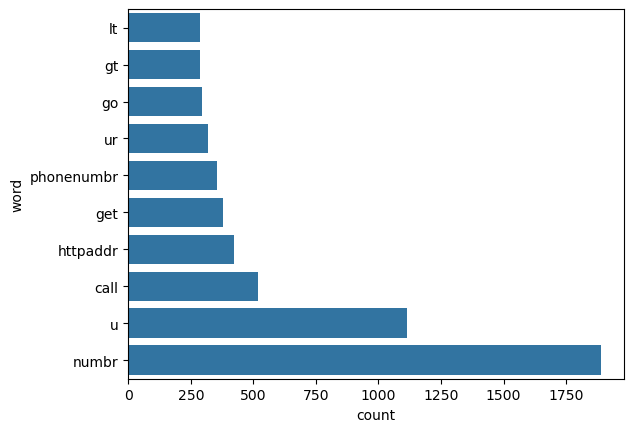

In [25]:
counter = collections.Counter([word for sentence in df["messages"] for word in sentence.split()])

df_counted = pd.DataFrame(counter.most_common(10),columns=["word","count"]).sort_values(by=["count"])
sns.barplot(df_counted,x="count",y="word",orient='horizontal')

Nous avons maintenant un jeu de donnée soigné et des messages contenant que les essentielles 

## Feature Extraction

Pour la feature extraction , on va utiliser la melange **word-level TF-IDF** avec ngram de **(1,2)** et **char-level TF-IDF** avec ngram de **(3,5)**\
Cette methode permet d'extraire les textes en maintenant une considération sémantique.

In [30]:
hybrid_extraction = FeatureUnion(
    [('word',TfidfVectorizer(max_features=4000,analyzer='word',ngram_range=(1,2),stop_words='english')),
     ('char',TfidfVectorizer(max_features=6000,analyzer='char',ngram_range=(3,5)))    
    ]
)
#X = hybrid_extraction.fit_transform(df["messages"]).toarray()
X = df["messages"]
Y = df.iloc[:,0]

- - -
## ENTRAINEMENT ET EVALUATION
Pour notre modèle , nous allons d'abord faire un separation de donnée d'entrainement et donnée de test

In [33]:
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,test_size=0.1,random_state=True)

Puis , On va créer trois modèle différents : 
- Support Vector Machine
- Multinomial Nayve Bayes
- Logistique Regression

### Support Vector Machine

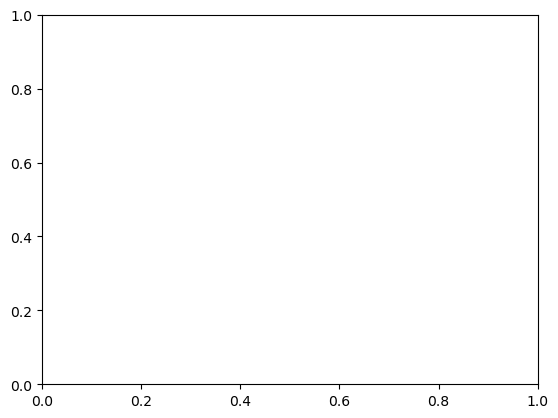

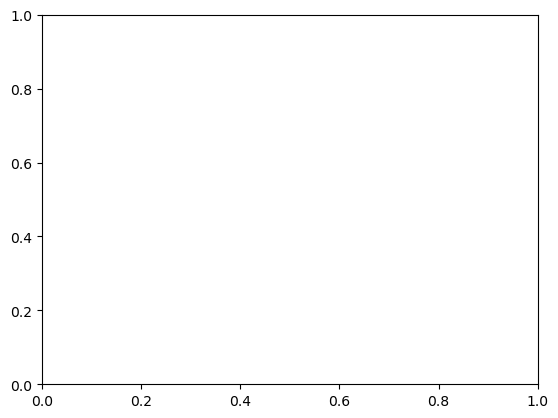

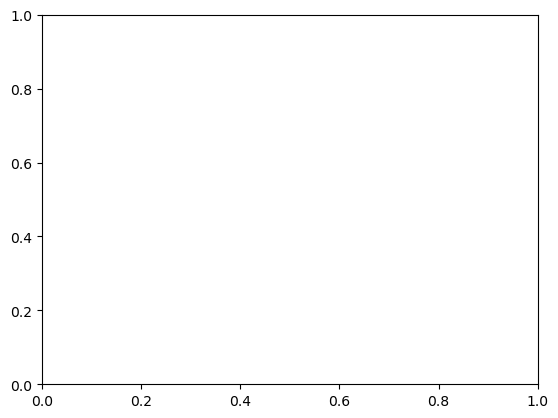

In [36]:
models = {
    'SVM' : SVC(),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Regression Logistique': LogisticRegression(max_iter=2000)
}
df_models = []
for k,v in models.items():
    model = Pipeline(
        [
            ('feature_extraction',FeatureUnion(
                                    [('word',TfidfVectorizer(max_features=4000,analyzer='word',ngram_range=(1,2),stop_words='english')),
                                     ('char',TfidfVectorizer(max_features=6000,analyzer='char',ngram_range=(3,5)))    
                                    ]
                                    )),
            ('model',v)
        ]
    )
    model.fit(xtrain,ytrain)
    y_pred = model.predict(xtest)
    accuracy = accuracy_score(y_pred=y_pred,y_true=ytest)
    accuracy = float(f"{accuracy*100:.2f}")
    precision = precision_score(y_pred=y_pred,y_true=ytest,pos_label='spam')
    precision = float(f"{precision*100:.2f}")
    f1 = f1_score(y_pred=y_pred,y_true=ytest,pos_label='spam')
    f1 = float(f"{f1*100:.2f}")
    recall = recall_score(y_pred=y_pred,y_true=ytest,pos_label='spam')
    recall = float(f"{recall*100:.2f}")
    df_models.append({
        'model_name':k,
        'accuracy':accuracy,
        'precision':precision,
        'recall':recall,
        'f1':f1
    })
    cm = confusion_matrix(y_pred=y_pred,y_true=ytest)
    
    #fig, ax = plt.subplots()
    #ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['ham','spam']).plot(ax=ax)
    #plt.title(f"Confusion Matrix - {k}")
    #plt.savefig(f"{k}_confusion_matrix.png")
    #plt.close(fig)
    #with open(f"{k}_model.pkl","wb") as file:
    #    pickle.dump(model, file)
df_models = pd.DataFrame(df_models)

In [38]:
df_models

,model_name,accuracy,precision,recall,f1
0,SVM,97.87,97.83,81.82,89.11
1,Multinomial Naive Bayes,97.49,86.21,90.91,88.50
2,Regression Logistique,97.29,95.56,78.18,86.00


In [46]:
df_melted = df_models.melt(
    id_vars="model_name", var_name="Metric", value_name="Score"
)

In [42]:
df_melted

,model_name,Metric,Score
0,SVM,accuracy,97.87
1,Multinomial Naive Bayes,accuracy,97.49
2,Regression Logistique,accuracy,97.29
3,SVM,precision,97.83
4,Multinomial Naive Bayes,precision,86.21
5,Regression Logistique,precision,95.56
6,SVM,recall,81.82
7,Multinomial Naive Bayes,recall,90.91
8,Regression Logistique,recall,78.18
9,SVM,f1,89.11


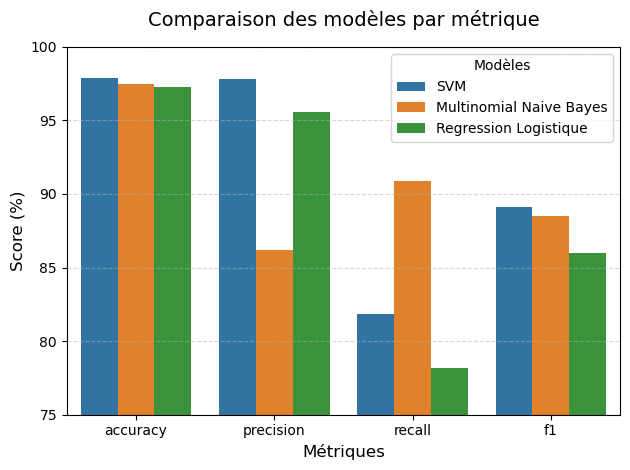

In [62]:
sns.barplot(x="Metric", y="Score", hue="model_name", data=df_melted)
plt.title("Comparaison des modèles par métrique", fontsize=14, pad=15)
plt.xlabel("Métriques", fontsize=12)
plt.ylabel("Score (%)", fontsize=12)
plt.ylim(75, 100)  # Zoom pour mieux visualiser les écarts
plt.legend(title="Modèles")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Affichage
plt.tight_layout()